# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Load Data

In [2]:
df = pd.read_csv(r"..\data\Unbalanced_product_reviews.csv", encoding='latin-1')

print("Imbalanced_product_reviews dataset shape:", df.shape)


Imbalanced_product_reviews dataset shape: (6330, 3)


# View Data

In [3]:

print("\nImbalanced_product_reviews dataset:")
df.head()
df.tail()
df.sample(5)
df.info()
df.describe()




Imbalanced_product_reviews dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6330 entries, 0 to 6329
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rating        6330 non-null   int64 
 1   Review        6330 non-null   object
 2   ReviewLength  6330 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 148.5+ KB


,Rating,ReviewLength
count,6330.000000,6330.000000
mean,3.350079,638.911058
std,1.235964,582.348072
min,1.000000,6.000000
25%,3.000000,246.000000
50%,3.500000,457.000000
75%,4.000000,844.000000
max,5.000000,4783.000000


#  Selecting Columns

In [4]:
df = df[['Rating','Review']]

print("Imbalanced_product_reviews dataset columns:", df.columns)

print("Imbalanced_product_reviews dataset shape:", df.shape)


Imbalanced_product_reviews dataset columns: Index(['Rating', 'Review'], dtype='object')
Imbalanced_product_reviews dataset shape: (6330, 2)


# Data Visualization of Imbalanced Data

# Rating Distribution (Bar Chart)

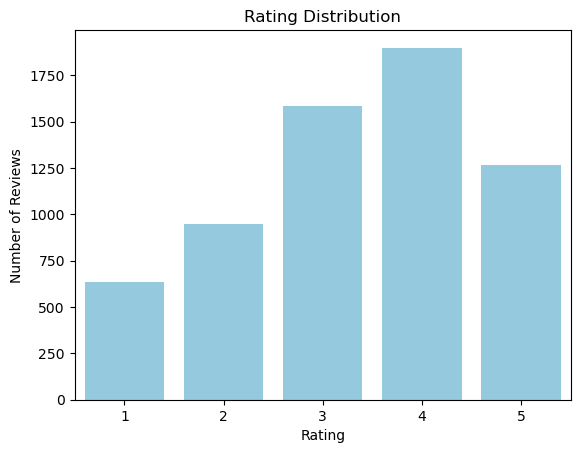

In [5]:
sns.countplot(x='Rating', data=df, color='skyblue')  
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# Rating Distribution (Pie Chart)

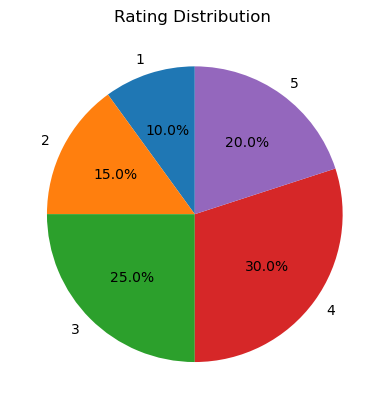

In [6]:

rating_counts = df['Rating'].value_counts().sort_index()

# Labels and values
categories = rating_counts.index
values = rating_counts.values

# Plot pie chart
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title("Rating Distribution ")
plt.show()


# Natural Language Processing (NLP)

# Lowercase All Text

In [7]:
df = df[['Rating', 'Review']]
# Convert Review text to lowercase
df['Review'] = df['Review'].str.lower()
# Reset index
df.reset_index(drop=True, inplace=True)

print(df.head())
print("Dataset shape:", df.shape)


   Rating                                             Review
0       1  this is one of the franchise store of ritz cam...
1       1  only reason for 1 star is cause i got arrested...
2       1  only reason for 1 star is cause i got arrested...
3       1  the only reason 1 star can be given is the fla...
4       1                                      very bad food
Dataset shape: (6330, 2)


# Remove URL

In [8]:
def remove_url(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)  # Replace URLs with empty string

df['Review'] = df['Review'].apply(remove_url)

df['Review'].head()


0    this is one of the franchise store of ritz cam...
1    only reason for 1 star is cause i got arrested...
2    only reason for 1 star is cause i got arrested...
3    the only reason 1 star can be given is the fla...
4                                        very bad food
Name: Review, dtype: object

# Remove HTML tags

In [9]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'',text)
df['Review'] =df['Review'].apply(remove_html_tags)

df['Review'].head()

0    this is one of the franchise store of ritz cam...
1    only reason for 1 star is cause i got arrested...
2    only reason for 1 star is cause i got arrested...
3    the only reason 1 star can be given is the fla...
4                                        very bad food
Name: Review, dtype: object

# Remove emojis, punctuation and special characters

In [10]:
import string

punctuation_list = string.punctuation
print(f'The punctuations are {punctuation_list}')



The punctuations are !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [11]:
def clean_text_punct(text):
    # Remove punctuation
    for char in punctuation_list:
        text = text.replace(char, '')
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

df['Review'] = df['Review'].apply(clean_text_punct)
df['Review'].head()

0    this is one of the franchise store of ritz cam...
1    only reason for 1 star is cause i got arrested...
2    only reason for 1 star is cause i got arrested...
3    the only reason 1 star can be given is the fla...
4                                        very bad food
Name: Review, dtype: object

# Showing stopwords 

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")

def show_stopwords_in_text(text):
    doc = nlp(text)
    present_stopwords = [token.text for token in doc if token.is_stop]
    return present_stopwords

df['Stopwords_in_Review'] = df['Review'].apply(show_stopwords_in_text)
df[['Review', 'Stopwords_in_Review']].head()

,Review,Stopwords_in_Review
0,this is one of the franchise store of ritz cam...,"[this, is, one, of, the, of, in, the, are, how..."
1,only reason for 1 star is cause i got arrested...,"[only, for, is, i, here, for, i, the, for, no]"
2,only reason for 1 star is cause i got arrested...,"[only, for, is, i, here, for, i, the, for, no]"
3,the only reason 1 star can be given is the fla...,"[the, only, can, be, is, the, and, the, i, hav..."
4,very bad food,[very]


# Remove stopwords

In [13]:
def remove_stopwords(text):
    doc = nlp(text)
    filtered_text = " ".join([token.text for token in doc if not token.is_stop])
    return filtered_text

df['Review'] = df['Review'].apply(remove_stopwords)
df['Review'].head()


0    franchise store ritz camera chandler stores st...
1    reason 1 star cause got arrested underaged dri...
2    reason 1 star cause got arrested underaged dri...
3    reason 1 star given flavor choices taste small...
4                                             bad food
Name: Review, dtype: object

# Apply Lemmatization

In [14]:
def lemmatize_text(text):
    doc = nlp(text)
    lemma_list = [token.lemma_ for token in doc]   # list format
    lemma_joined = " ".join(lemma_list)            # joined format
    return lemma_list, lemma_joined

# Apply and expand into two columns
df[['Review_List', 'REVIEW']] = df['Review'].apply(lambda x: pd.Series(lemmatize_text(x)))

print("List format:\n", df['Review_List'].head())
print("\nJoined format:\n", df['REVIEW'].head())



List format:
 0    [franchise, store, ritz, camera, chandler, sto...
1    [reason, 1, star, cause, get, arrest, underage...
2    [reason, 1, star, cause, get, arrest, underage...
3    [reason, 1, star, give, flavor, choice, taste,...
4                                          [bad, food]
Name: Review_List, dtype: object

Joined format:
 0    franchise store ritz camera chandler store sta...
1    reason 1 star cause get arrest underaged drink...
2    reason 1 star cause get arrest underaged drink...
3    reason 1 star give flavor choice taste small w...
4                                             bad food
Name: REVIEW, dtype: object


# Filter out reviews with: Fewer than minimum words and Excessively long text

In [15]:
# Calculate word count for each review
df['Word_Count'] = df['REVIEW'].apply(lambda x: len(x.split()))

df = df[(df['Word_Count'] >= 3) & (df['Word_Count'] <= 250)]

# Check the filtered dataset
print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df.shape)
df[['REVIEW', 'Word_Count']].head()


Original dataset shape: (6243, 6)
Filtered dataset shape: (6243, 6)


,REVIEW,Word_Count
0,franchise store ritz camera chandler store sta...,58
1,reason 1 star cause get arrest underaged drink...,14
2,reason 1 star cause get arrest underaged drink...,14
3,reason 1 star give flavor choice taste small w...,17
5,disappoint local baja fresh tonight lobby sals...,24


# Data Visualization

# Bar plot: Review count per rating

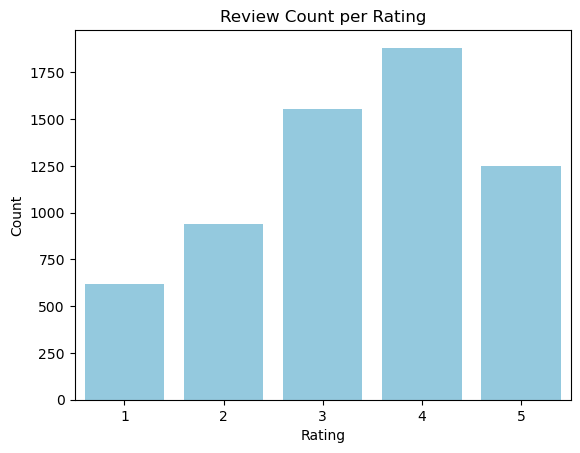

In [17]:
sns.countplot(x='Rating', data=df, color='skyblue')
plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Word count 

In [18]:
df.loc[:, 'Word_Count'] = df['REVIEW'].str.split().str.len()

df[['REVIEW', 'Word_Count']].head()



,REVIEW,Word_Count
0,franchise store ritz camera chandler store sta...,58
1,reason 1 star cause get arrest underaged drink...,14
2,reason 1 star cause get arrest underaged drink...,14
3,reason 1 star give flavor choice taste small w...,17
5,disappoint local baja fresh tonight lobby sals...,24


# Histogram for Word Count

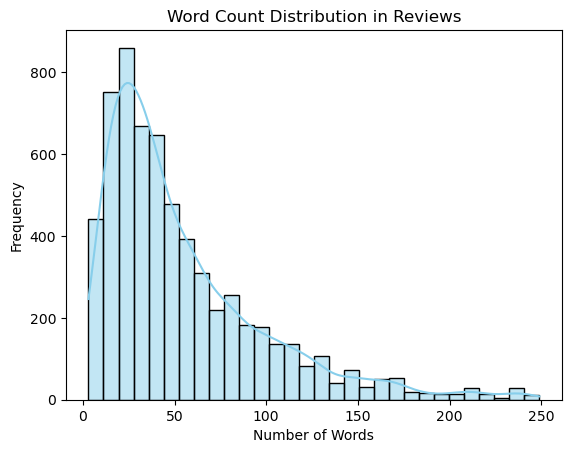

In [19]:

sns.histplot(df['Word_Count'], bins=30, kde=True, color='skyblue')
plt.title('Word Count Distribution in Reviews')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Box Plot: Word count by Rating

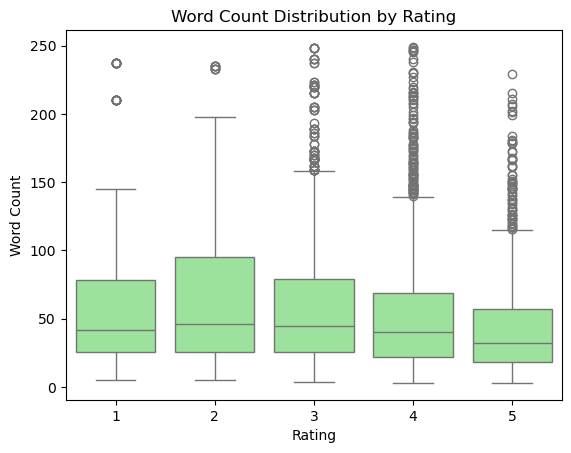

In [20]:


sns.boxplot(x='Rating', y='Word_Count', data=df, color='lightgreen')
plt.title('Word Count Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.show()

# full sample reviews per rating

In [21]:
for rating, group in df.groupby('Rating'):
    print(f"\n--- Rating: {rating} ---\n")
    sample_reviews = df[df['Rating'] == rating]['REVIEW'].sample(
        n=min(5, len(df[df['Rating'] == rating])),
        random_state=42)
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review}\n")



--- Rating: 1 ---

1. ve hard time sonic location barely speak english not know menu mess order 2 time come job confusing

2. hear good thing place look forward basement atmosphere feel like lowbrow little seedy etc sadly middleage man wear flip flop friday night flip flop ughin winter waiter suck act like hard night unwilling suggest beer sure spit draftanyhoo matter return

3. bitzee mamas not mama mama not keep hungry son wait forever lunch not let thirsty refill good bowl salsa make alright right take real mama lunch order taco salad ma order cheese enchilada plate bowl red chile taco salad alright taco shell mushy water literally fall apart pick glad not eat shell s old school make darn good cheese enchilada refrie bean strike red chile swear la canasta red chile meat tender sauce smooth weird orange color meat taste not beef ve way counter pay bill notice eat chimichangas look like order wrong thing place uber cheap careful order mama fine

4. gross plain simple ill crave quick 

# Shuffle the dataset

In [22]:
# Shuffle the balanced dataset
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_shuffled[['REVIEW', 'Rating']].head()


,REVIEW,Rating
0,es como volver al pasado la universidad es de ...,5
1,want stop try thing stop bad rumor clean clean...,3
2,merupakan sekolah utama di dunia yang dalam bi...,4
3,like quaint little restaurant space bit crowd ...,3
4,love old menu change give change heart good sa...,3


# Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X = df['REVIEW']   # Text data
y = df['Rating']          # Target labels

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))


Training set size: 4994
Test set size: 1249


# Preprocessing

In [24]:

nlp = spacy.load('en_core_web_sm')

def spacy_preprocess(text):
    doc = nlp(text.lower())  # Lowercase and tokenize
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)


In [25]:
# Preprocess training set
X_train_processed = X_train.apply(spacy_preprocess)

# Preprocess test set
X_test_processed = X_test.apply(spacy_preprocess)

print("X_train_preprocessed:")
print(X_train_processed.head())
print("X_test_preprocessed:")
print(X_test_processed.head())



X_train_preprocessed:
2332    s like stingray stylish sushi happy hours fine...
1222    reason people think ok price tank probably thr...
6083    great experience havana cafe everybody super n...
4405    spend time walking area decide tour add lot co...
2895    visit campus great people interested place bui...
Name: REVIEW, dtype: object
X_test_preprocessed:
5594    indian having grow london pretty spoilt indian...
4133    good burger ve great view patio enjoy wonderfu...
5069    great fast consistent service excellent staff ...
5599    limited time thing right bbq chicken pizza sur...
1971    love n burger particular location kind lack or...
Name: REVIEW, dtype: object


# Vectorize text using:TF-IDF

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2), stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
print("TF-IDF training set shape:", X_train_tfidf.shape)

X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)
print("TF-IDF test set shape:", X_test_tfidf.shape)



TF-IDF training set shape: (4994, 5000)
TF-IDF test set shape: (1249, 5000)


In [27]:
print("Number of features in TF-IDF:", len(tfidf_vectorizer.get_feature_names_out()))
print("Sample features:", tfidf_vectorizer.get_feature_names_out()[:30])


Number of features in TF-IDF: 5000
Sample features: ['able' 'absolute' 'absolutely' 'absolutely love' 'ac' 'academic' 'accent'
 'accept' 'access' 'accessible' 'accommodate' 'accompany' 'accord'
 'account' 'acknowledge' 'acknowledgement' 'acoustic' 'act' 'act like'
 'activity' 'actual' 'actually' 'actually like' 'actually lol'
 'actually open' 'actually pretty' 'actually screw' 'actually want' 'ad'
 'add']


# Original Reviews and Ratings for Training and Test Sets

In [28]:
# Training set
print("REVIEW and Rating from training set:")
train_df_sample = pd.DataFrame({'REVIEW': X_train, 'Rating': y_train}).reset_index(drop=True)
print(train_df_sample.head(), "\n")  # Added \n for separation

# Test set
print("REVIEW and Rating from test set:")
test_df_sample = pd.DataFrame({'REVIEW': X_test, 'Rating': y_test}).reset_index(drop=True)
print(test_df_sample.head())


REVIEW and Rating from training set:
                                              REVIEW  Rating
0  s like stingray stylish sushi happy hours fine...       3
1  reason people think ok price tank probably thr...       2
2  great experience havana cafe everybody super n...       5
3  spend time walking area decide tour add lot co...       4
4  go visit campus great people interested place ...       3 

REVIEW and Rating from test set:
                                              REVIEW  Rating
0  indian having grow london pretty spoilt indian...       5
1  good burger ve great view patio enjoy wonderfu...       4
2  great fast consistent service excellent staff ...       5
3  limited time thing go right bbq chicken pizza ...       5
4  love n burger particular location kind lack or...       3


# Top TF-IDF Features per Review with Corresponding Ratings

In [29]:

def top_tfidf_features_per_review(tfidf_matrix, feature_names, ratings, top_n=5):
  
    # Ensure dense format
    if not isinstance(tfidf_matrix, np.ndarray):
        tfidf_dense = tfidf_matrix.toarray()
    else:
        tfidf_dense = tfidf_matrix

    top_features_list = []

    for i in range(tfidf_dense.shape[0]):
        row = tfidf_dense[i]
        top_indices = row.argsort()[-top_n:][::-1]  # Indices of top N features
        top_features = [feature_names[idx] for idx in top_indices]
        top_scores = [row[idx] for idx in top_indices]
        
        top_features_list.append({
            'Rating': ratings.iloc[i] if hasattr(ratings, 'iloc') else ratings[i],
            'Top_Features': top_features,
            'TF-IDF_Scores': top_scores
        })

    return pd.DataFrame(top_features_list)

feature_names = tfidf_vectorizer.get_feature_names_out()
top_features_df = top_tfidf_features_per_review(X_train_tfidf, feature_names, y_train, top_n=5)

top_features_df.head()


,Rating,Top_Features,TF-IDF_Scores
0,3,"[sushi, roll, sushi roll, happy, salmon]","[0.5157562635627507, 0.27460465220646413, 0.22..."
1,2,"[tempe, thong, thread, labor, blind]","[0.35674602312434267, 0.2740070834215279, 0.27..."
2,5,"[overall good, ah, nice service, experience, w...","[0.2673571777579024, 0.2614957620131819, 0.258..."
3,4,"[tour, sink, lot, joke, spend time]","[0.34622357474298215, 0.29840651101323945, 0.2..."
4,3,"[mean, campus great, campus, memorial hall, gr...","[0.26221843552887464, 0.21725770757101906, 0.2..."
